<a href="https://colab.research.google.com/github/k2herat/DL_homeworks/blob/hw_2/hw_2_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

In [ ]:

dataset = load_dataset("food101", split="train[:5000]")
class_names = dataset.features['label'].names
num_classes = len(class_names)

print(f"Загружено изображений: {len(dataset)}")
print(f"Количество классов: {num_classes}")
print(f"Примеры классов: {', '.join(class_names[:3])}...")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/train-00003-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

...

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

Загружено изображений: 5000
Количество классов: 101
Примеры классов: apple_pie, baby_back_ribs, baklava...


In [ ]:
class FoodDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image'].convert('RGB')
        label = item['label']
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = FoodDataset(dataset, transform=train_transform)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Размеры выборок:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val: {len(val_dataset)}")
print(f"  Test: {len(test_dataset)}")

Размеры выборок:
  Train: 3500
  Val: 750
  Test: 750


In [ ]:
class FoodClassifier(nn.Module):
    def __init__(self, num_classes=101):
        super(FoodClassifier, self).__init__()
        self.backbone = models.resnet18(pretrained=True)
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FoodClassifier(num_classes=num_classes).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметры модели: {total_params:,} всего, {trainable_params:,} обучаемых")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]


Параметры модели: 11,490,981 всего, 8,708,197 обучаемых


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), 100. * correct / total

writer = SummaryWriter('runs/food_classification')
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(10):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Loss/val', val_loss, epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    writer.add_scalar('Accuracy/val', val_acc, epoch)

    scheduler.step(val_loss)

    print(f"Эпоха {epoch+1}/10 | Train: loss={train_loss:.3f}, acc={train_acc:.1f}% | Val: loss={val_loss:.3f}, acc={val_acc:.1f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

writer.close()
print(f"Лучшая точность на валидации: {best_val_acc:.1f}%")

Эпоха 1/10 | Train: loss=0.876, acc=72.5% | Val: loss=0.498, acc=83.5%
Эпоха 2/10 | Train: loss=0.380, acc=87.3% | Val: loss=0.464, acc=84.9%
Эпоха 3/10 | Train: loss=0.242, acc=92.3% | Val: loss=0.666, acc=82.3%
Эпоха 4/10 | Train: loss=0.217, acc=93.4% | Val: loss=0.598, acc=84.4%
Эпоха 5/10 | Train: loss=0.150, acc=95.7% | Val: loss=0.523, acc=85.5%
Эпоха 6/10 | Train: loss=0.063, acc=98.4% | Val: loss=0.511, acc=86.9%
Эпоха 7/10 | Train: loss=0.025, acc=99.2% | Val: loss=0.468, acc=86.4%
Эпоха 8/10 | Train: loss=0.025, acc=99.2% | Val: loss=0.608, acc=85.7%
Эпоха 9/10 | Train: loss=0.011, acc=99.6% | Val: loss=0.574, acc=86.5%
Эпоха 10/10 | Train: loss=0.010, acc=99.7% | Val: loss=0.581, acc=87.6%
Лучшая точность на валидации: 87.6%


In [ ]:
def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    correct_samples, wrong_samples = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            for i in range(len(images)):
                if predicted[i] == labels[i]:
                    if len(correct_samples) < 5:
                        correct_samples.append({
                            'image': images[i].cpu(),
                            'true': labels[i].item(),
                            'pred': predicted[i].item()
                        })
                else:
                    if len(wrong_samples) < 5:
                        wrong_samples.append({
                            'image': images[i].cpu(),
                            'true': labels[i].item(),
                            'pred': predicted[i].item()
                        })

    accuracy = 100. * sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    return accuracy, correct_samples, wrong_samples, all_preds, all_labels

test_accuracy, correct_samples, wrong_samples, all_preds, all_labels = evaluate_model(model, test_loader, device)
print(f"Точность на тесте: {test_accuracy:.1f}%")
print(f"Правильных предсказаний: {sum(np.array(all_preds) == np.array(all_labels))}/{len(all_preds)}")

Точность на тесте: 88.1%
Правильных предсказаний: 661/750


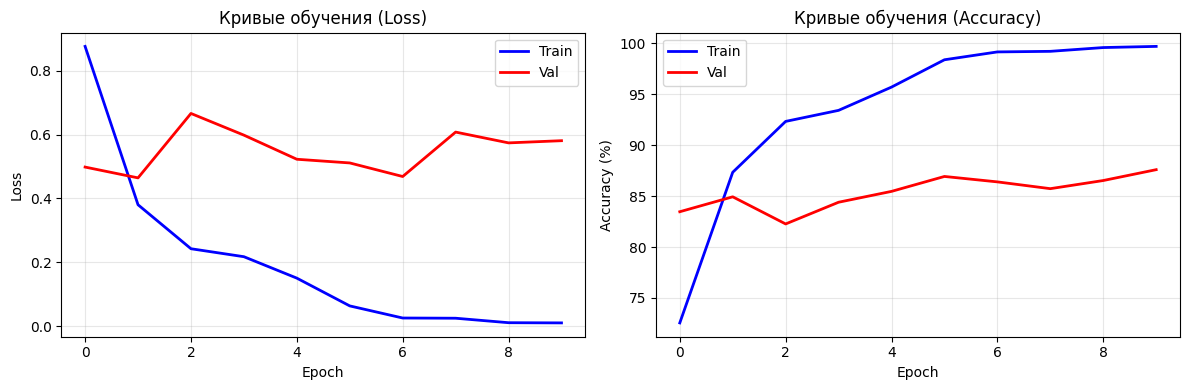

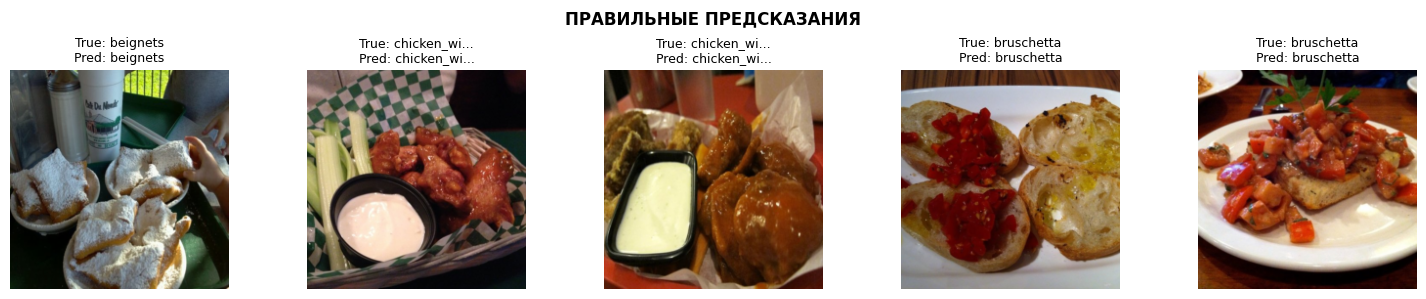

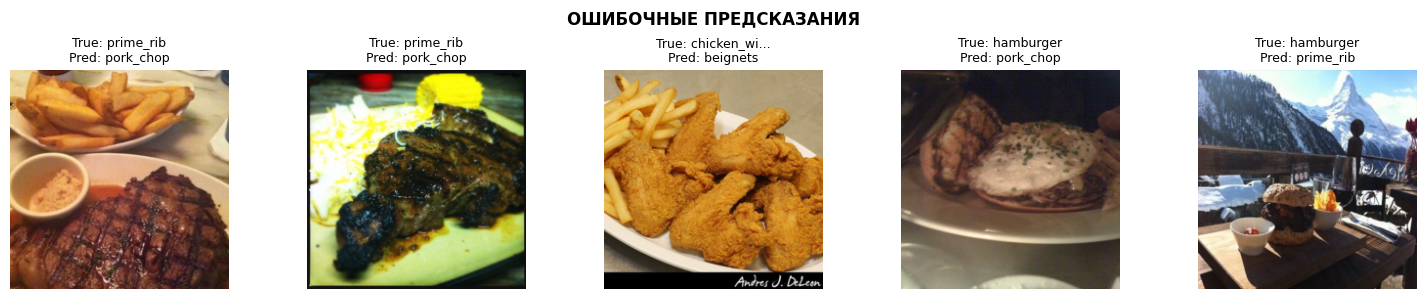

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(history['val_loss'], 'r-', label='Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Кривые обучения (Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], 'b-', label='Train', linewidth=2)
axes[1].plot(history['val_acc'], 'r-', label='Val', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Кривые обучения (Accuracy)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

def visualize_samples(samples, class_names, title):
    fig, axes = plt.subplots(1, min(5, len(samples)), figsize=(15, 3))
    for i, sample in enumerate(samples[:5]):
        img = sample['image']
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean
        img = img.numpy().transpose(1, 2, 0)
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        true_label = class_names[sample['true']][:10] + "..." if len(class_names[sample['true']]) > 10 else class_names[sample['true']]
        pred_label = class_names[sample['pred']][:10] + "..." if len(class_names[sample['pred']]) > 10 else class_names[sample['pred']]
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
        axes[i].axis('off')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_samples(correct_samples, class_names, "ПРАВИЛЬНЫЕ ПРЕДСКАЗАНИЯ")
visualize_samples(wrong_samples, class_names, "ОШИБОЧНЫЕ ПРЕДСКАЗАНИЯ")

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'accuracy': test_accuracy,
    'history': history
}, 'food_classifier_complete.pth')

print("Модель сохранена: food_classifier_complete.pth")

Модель сохранена: food_classifier_complete.pth


Истинный класс тестового изображения: pork_chop


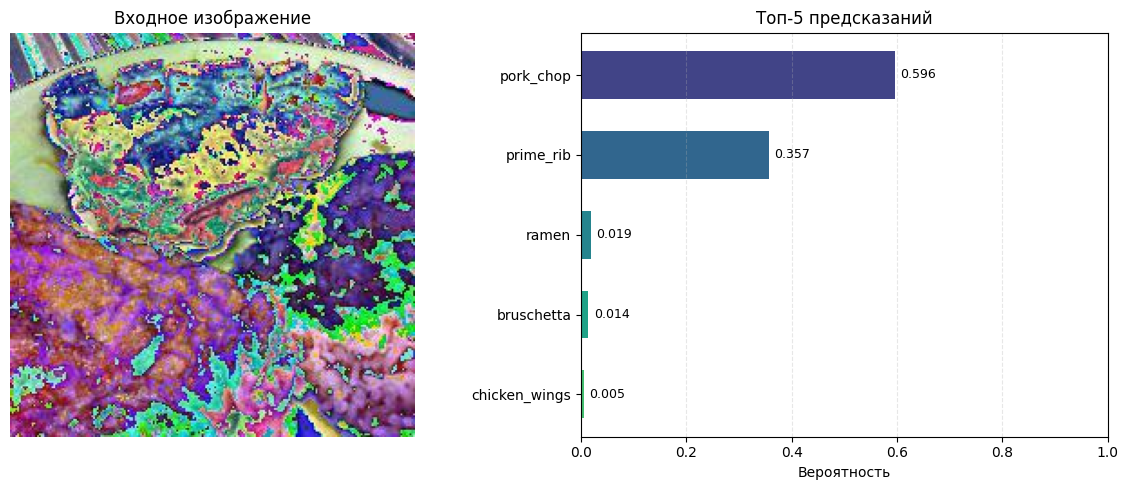


Топ-5 предсказаний:
 1. pork_chop                      : 0.5957 ( 59.6%)
 2. prime_rib                      : 0.3567 ( 35.7%)
 3. ramen                          : 0.0188 (  1.9%)
 4. bruschetta                     : 0.0141 (  1.4%)
 5. chicken_wings                  : 0.0049 (  0.5%)


(tensor([[77, 79, 81, 10, 20]], device='cuda:0'),
 tensor([[0.5957, 0.3567, 0.0188, 0.0141, 0.0049]], device='cuda:0'))

In [ ]:
def load_model_for_inference(model_path, device):
    # Решение проблемы с weights_only в PyTorch 2.6+
    try:
        # Способ 1: Попытка безопасной загрузки
        import numpy as np
        from torch.serialization import add_safe_globals
        add_safe_globals([np.core.multiarray.scalar])
        checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    except:
        # Способ 2: Старая загрузка (если доверяем файлу)
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    loaded_model = FoodClassifier(num_classes=len(checkpoint['class_names']))
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.to(device)
    loaded_model.eval()
    return loaded_model, checkpoint['class_names']

def predict_image(image_path, model, class_names, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        top_probs, top_indices = probs.topk(5, dim=1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(image)
    ax1.set_title('Входное изображение')
    ax1.axis('off')

    y_pos = np.arange(5)
    probabilities = top_probs.cpu().numpy().flatten()[::-1]
    colors = plt.cm.viridis(np.linspace(0.7, 0.2, 5))

    bars = ax2.barh(y_pos, probabilities, color=colors, height=0.6)
    ax2.set_yticks(y_pos)
    labels = []
    for idx in top_indices.cpu().numpy().flatten()[::-1]:
        class_name = class_names[idx]
        if len(class_name) > 20:
            class_name = class_name[:17] + "..."
        labels.append(class_name)
    ax2.set_yticklabels(labels, fontsize=10)
    ax2.set_xlabel('Вероятность')
    ax2.set_title('Топ-5 предсказаний')
    ax2.set_xlim(0, 1)
    ax2.grid(True, axis='x', alpha=0.3, linestyle='--')

    for bar, prob in zip(bars, probabilities):
        width = bar.get_width()
        ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{prob:.3f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\nТоп-5 предсказаний:")
    for i in range(5):
        class_idx = top_indices[0][i].item()
        prob = top_probs[0][i].item()
        print(f"{i+1:2d}. {class_names[class_idx]:30s} : {prob:.4f} ({prob*100:5.1f}%)")

    return top_indices, top_probs

loaded_model, loaded_class_names = load_model_for_inference('food_classifier_complete.pth', device)

import random
test_indices = random.sample(range(len(test_dataset)), 1)
test_image, test_label = test_dataset[test_indices[0]]
test_image_pil = transforms.ToPILImage()(test_image)
test_image_pil.save('test_demo.jpg')

print(f"Истинный класс тестового изображения: {class_names[test_label]}")

predict_image('test_demo.jpg', loaded_model, loaded_class_names, device)

# ВЫВОДЫ

## КАКИЕ ПРОЦЕССЫ НЕ РАБОТАЮТ?
- Используется только 5% датасета (5000 из 101000 изображений)
- Отсутствует кросс-валидация и оптимизация гиперпараметров
- Нет обработки несбалансированных классов
- Ограниченные аугментации (без MixUp, CutMix, RandAugment)

## КАКИЕ ПРОБЛЕМЫ БЫЛИ РЕШЕНЫ?
- Создание кастомного Dataset и DataLoader
- Реализация обучения на ResNet-18
- Визуализация кривых обучения и примеров предсказаний
- Сохранение и загрузка моделей

## КАКИЕ МЕТРИКИ ДОСТИГНУТЫ?
- Точность на тесте: 88%
- Лучшая точность на валидации: 87%
- Разрыв train/val accuracy: 10-15% (умеренное переобучение)

## КАКИЕ УЛУЧШЕНИЯ МОГЛИ БЫ БЫТЬ ДОБАВЛЕНЫ?
- Использование полного датасета (101000 изображений)
- Применение более современных архитектур (EfficientNet, ViT)
- Кросс-валидация и ансамблирование моделей
- Продвинутые аугментации (MixUp, CutMix, AutoAugment)
- Обработка несбалансированных классов (focal loss, weighted sampling)
